## Timing Plots

In [2]:
import csv

import matplotlib.pyplot as plt
import numpy as np

range(12, 25)


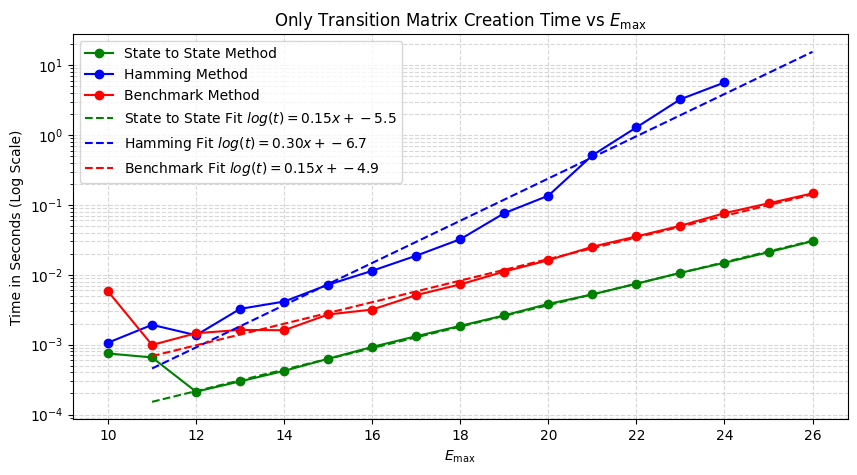

In [56]:
# 1. Parameters for the plot

emax_list = range(10,27) #Test Range of E_max.

# 2. Importing comparison timings. This file is produced from the old code and imported here.
benchmark_filename = "benchmark_results.csv"
execution_times_benchmark = []
with open(benchmark_filename, mode="r") as file:
    reader = csv.reader(file)
    next(reader) #Skips Header.
    for row in reader:
        execution_times_benchmark.append(float(row[1])) # Convert time back to float

statestate_filename = "statestate_results.csv"
execution_times_statestate = []
with open(statestate_filename, mode="r") as file:
    reader = csv.reader(file)
    next(reader) #Skips Header.
    for row in reader:
        execution_times_statestate.append(float(row[1])) # Convert time back to float

hamming_filename = "hamming_results.csv"
execution_times_hamming = []
with open(hamming_filename, mode="r") as file:
    reader = csv.reader(file)
    next(reader) #Skips Header.
    for row in reader:
        execution_times_hamming.append(float(row[1])) # Convert time back to float


# 3. Plot the results
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.set_xlabel(r'$E_\text{max}$', color='black')
ax1.set_ylabel('Time in Seconds (Log Scale)')
ax1.set_yscale('log')
ax1.tick_params(axis='x', labelcolor='black')
ax1.grid(True, which="both", linestyle='--', alpha=0.5)

ax1.plot(emax_list, execution_times_statestate, marker='o', linestyle='-', color='g', label='State to State Method')
ax1.plot(emax_list[:-2], execution_times_hamming, marker='o', linestyle='-', color='b', label='Hamming Method')
ax1.plot(emax_list, execution_times_benchmark, marker ='o', linestyle='-', color='r', label='Benchmark Method')

# 4. First degree polynomial fit to the timing data.
startix = 2
coef_statestate = (np.polyfit(emax_list[startix:], np.log10(execution_times_statestate)[startix:], 1))
print(emax_list[startix:-2])
coef_hamming = (np.polyfit(emax_list[startix:-2], np.log10(execution_times_hamming)[startix:], 1))
coef_bench = (np.polyfit(emax_list[startix:], np.log10(execution_times_benchmark)[startix:], 1))

poly_statestate = np.poly1d(coef_statestate)
poly_hamming = np.poly1d(coef_hamming)
poly_bench = np.poly1d(coef_bench)
xs = np.linspace(emax_list[1],emax_list[-1])

ax1.plot(xs, 10**poly_statestate(xs), linestyle='--', color='g', label=f'State to State Fit $log(t)={coef_statestate[0]:.2f}x+{coef_statestate[1]:.1f}$')
ax1.plot(xs, 10**poly_hamming(xs), linestyle='--', color='b', label=f'Hamming Fit $log(t)={coef_hamming[0]:.2f}x+{coef_hamming[1]:.1f}$')
ax1.plot(xs, 10**poly_bench(xs), linestyle='--', color='r', label=f'Benchmark Fit $log(t)={coef_bench[0]:.2f}x+{coef_bench[1]:.1f}$')
ax1.legend()



plt.title(r'Transition Matrix Creation Time vs $E_\text{max}$')
plt.show()
